# 07 — Complete Growth workflow: from KPI change to an experiment decision

**Graduate course: Decomposition Analysis in Python**

## Learning objectives

- Translate a KPI alert into an auditable analytical contract.
- Separate known-segment decomposition from adaptive subgroup discovery.
- Build an honest HCD-style tree whose leaf contributions conserve the KPI change.
- Convert a replicated descriptive pattern into a testable mechanism.
- Estimate experimental lift and connect it to an economic launch decision.
- Produce a final Growth readout without confusing contribution, prediction, and causation.

## The workflow

```text
Metric contract → data QA → aggregate change
      ↓
Known segmentation → exact Kitagawa mix/rate decomposition
      ↓
Discovery sample → regularized CART/HCD candidate hierarchy
      ↓
Holdout sample → exact leaf ledger + uncertainty + stability
      ↓
Mechanism hypothesis → randomized experiment
      ↓
Causal lift → incremental conversions → economic decision
```

The stages answer different questions:

| Stage | Question | Permitted claim |
|---|---|---|
| Monitoring | Did the KPI move? | observed change |
| Kitagawa | How is the change allocated across known cells? | descriptive contribution |
| HCD discovery | Where is the change concentrated? | replicated descriptive localization |
| Experiment | Does the intervention change the KPI? | causal effect under the design |
| Economics | Is rollout valuable at relevant scale? | decision conditional on costs and transport |

No arrow automatically upgrades the previous result into a causal statement.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
from pathlib import Path
from itertools import permutations
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeRegressor, export_text

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from scripts.rate_decomposition import kitagawa_two_period

pd.options.display.float_format = '{:,.4f}'.format
rng = np.random.default_rng(2027)
plt.style.use('seaborn-v0_8-whitegrid')

## 1. Write the metric and decision contract first

**Scenario.** Monthly website conversion rate fell. The team wants to know where the movement occurred and whether a new mobile landing experience should be tested.

The contract is:

- **population:** eligible web sessions, excluding bots and internal traffic;
- **unit:** session;
- **numerator:** sessions with a purchase inside the attribution window;
- **denominator:** eligible sessions;
- **contrast:** comparison month minus baseline month;
- **known reporting dimensions:** channel and device;
- **discovery dimensions:** channel, device, market, intent, and tenure;
- **decision:** launch a landing-page intervention only if replicated incremental value exceeds cost;
- **causal status:** the monthly contrast is descriptive; only the later randomized treatment identifies lift.

Changing any of these definitions changes the estimand.

## 2. Simulate two monthly populations

The simulation contains both composition drift and within-segment performance changes. Paid Search receives more traffic, while high-intent Paid Search mobile sessions deteriorate. Social desktop improves slightly. This structure lets us test whether the workflow distinguishes aggregate allocation from local pattern discovery.

In [2]:
def simulate_month(period, n):
    channel_p = ([.32, .43, .25] if period == 0 else [.40, .36, .24])
    data = pd.DataFrame({
        'period': period,
        'channel': rng.choice(['Paid Search', 'Organic', 'Social'], n,
                              p=channel_p),
        'device': rng.choice(['Mobile', 'Desktop'], n, p=[.70, .30]),
        'market': rng.choice(['Lima', 'Mexico City', 'Bogota'], n,
                             p=[.35, .38, .27]),
        'high_intent': rng.binomial(1, .38, n),
        'tenure_months': rng.gamma(2.1, 5.5, n).clip(0, 36),
    })
    logit = (
        -2.75
        + .28 * data.high_intent
        + .30 * data.device.eq('Desktop')
        + .16 * data.channel.eq('Paid Search')
        + .012 * data.tenure_months
    )
    period_shift = (
        -.05
        - .72 * (data.channel.eq('Paid Search')
                 & data.device.eq('Mobile') & data.high_intent.eq(1))
        + .32 * (data.channel.eq('Social') & data.device.eq('Desktop'))
        + .16 * (data.market.eq('Lima') & data.tenure_months.ge(12))
    )
    probability = 1 / (1 + np.exp(-(logit + period * period_shift)))
    data['converted'] = rng.binomial(1, probability)
    return data

events = pd.concat([
    simulate_month(0, 14_000),
    simulate_month(1, 14_000),
], ignore_index=True)

metric = events.groupby('period').converted.agg(['sum', 'count', 'mean'])
metric.loc['change', 'mean'] = metric.loc[1, 'mean'] - metric.loc[0, 'mean']
metric

,sum,count,mean
period,,,
0,"1,227.0000","14,000.0000",0.0876
1,"1,140.0000","14,000.0000",0.0814
change,NaN,NaN,-0.0062


## 3. Data-quality gate

Before explaining a movement, verify that it is not a broken metric. At minimum check uniqueness of the analysis unit, missing dimensions, invalid outcome values, denominator volume, period coverage, and category drift. A production workflow should also compare event-schema versions, bot filters, consent logic, attribution windows, and late-arriving events.

In [3]:
qa = pd.Series({
    'rows': len(events),
    'duplicate index': events.index.duplicated().sum(),
    'missing key dimensions': events[
        ['period', 'channel', 'device', 'market', 'converted']
    ].isna().any(axis=1).sum(),
    'invalid outcomes': (~events.converted.isin([0, 1])).sum(),
    'baseline denominator': events.period.eq(0).sum(),
    'comparison denominator': events.period.eq(1).sum(),
})
channel_volume = pd.crosstab(events.channel, events.period, normalize='columns')
qa, channel_volume

(rows                      28000
 duplicate index               0
 missing key dimensions        0
 invalid outcomes              0
 baseline denominator      14000
 comparison denominator    14000
 dtype: int64,
 period           0      1
 channel                  
 Organic     0.4329 0.3629
 Paid Search 0.3193 0.3989
 Social      0.2478 0.2382)

## 4. Known-segment decomposition with Kitagawa

First use the business hierarchy already understood by stakeholders. For joint cell $g=\text{channel}\times\text{device}$,

$$R_t=\sum_g w_{gt}r_{gt}.$$

Kitagawa allocates the observed change exactly:

$$\Delta R=\sum_g
(w_{g1}-w_{g0})\frac{r_{g1}+r_{g0}}{2}
+\sum_g(r_{g1}-r_{g0})\frac{w_{g1}+w_{g0}}{2}.$$

This stage answers whether the aggregate movement is mainly associated with **joint channel × device composition** or performance inside those joint cells. It does not separately attribute composition to channel and device, because the joint share vector $w_{gt}$ is treated as one changing block.

In [4]:
cell = (
    events.groupby(['period', 'channel', 'device'])
    .converted.agg(['mean', 'size']).reset_index()
)
cell['weight'] = cell['size'] / cell.groupby('period')['size'].transform('sum')
wide = cell.pivot(index=['channel', 'device'], columns='period',
                  values=['weight', 'mean']).reset_index()
wide.columns = ['channel', 'device', 'w0', 'w1', 'r0', 'r1']
wide['segment'] = wide.channel + ' × ' + wide.device

kitagawa = kitagawa_two_period(
    wide[['segment', 'w0', 'w1', 'r0', 'r1']]
)
known_ledger = kitagawa.detail.set_index('segment')[
    ['w0', 'w1', 'r0', 'r1', 'mix', 'rate', 'total_contribution']
].sort_values('total_contribution')
kitagawa.summary, known_ledger

(R0                  0.0876
 R1                  0.0814
 observed_change    -0.0062
 mix                 0.0007
 rate               -0.0069
 entry_exit          0.0000
 allocated_change   -0.0062
 identity_error     -0.0000
 dtype: float64,
                           w0     w1     r0     r1     mix    rate  \
 segment                                                             
 Paid Search × Mobile  0.2271 0.2802 0.0962 0.0607  0.0042 -0.0090   
 Organic × Desktop     0.1317 0.1120 0.0987 0.0925 -0.0019 -0.0008   
 Social × Mobile       0.1749 0.1646 0.0801 0.0746 -0.0008 -0.0009   
 Organic × Mobile      0.3012 0.2509 0.0704 0.0806 -0.0038  0.0028   
 Paid Search × Desktop 0.0921 0.1186 0.1163 0.1066  0.0030 -0.0010   
 Social × Desktop      0.0729 0.0736 0.0940 0.1214  0.0001  0.0020   
 
                        total_contribution  
 segment                                    
 Paid Search × Mobile              -0.0049  
 Organic × Desktop                 -0.0026  
 Social × Mobile 

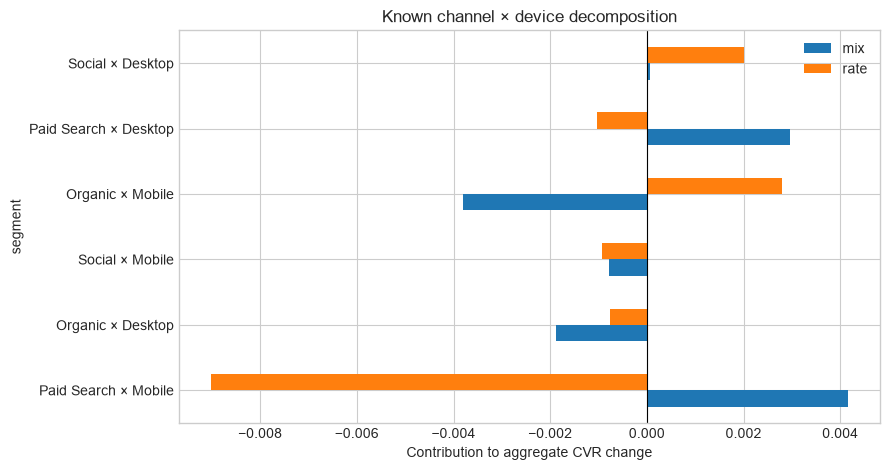

In [5]:
known_ledger[['mix', 'rate']].plot.barh(figsize=(9, 4.8))
plt.axvline(0, color='black', linewidth=.8)
plt.xlabel('Contribution to aggregate CVR change')
plt.title('Known channel × device decomposition')
plt.tight_layout()
plt.show()

## 4.1 Should Growth use Kitagawa, Das Gupta, or Shapley?

The answer depends on the question—not on which method sounds more advanced.

### Kitagawa is preferable when

- the KPI is a weighted rate;
- segments form one declared partition;
- the desired distinction is **joint composition versus within-cell rate**;
- stakeholders can act on the joint cells;
- a transparent two-component ledger is more valuable than finer attribution.

For `channel × device`, Kitagawa treats the six joint shares as one composition vector. It is exact and robust, but cannot say how much of composition is specifically “channel” versus “device.”

### Das Gupta is preferable when

- there are several scientifically distinct changing blocks;
- the analyst can define coherent standardized populations;
- the question requires a separate allocation to channel, device-within-channel, and cell rate;
- interaction allocation and factorization sensitivity are reported.

Use the sequential factorization

$$R_t=\sum_i p_{it}\sum_j q_{j\mid i,t}r_{ijt},$$

where $p_{it}=P_t(\text{channel}=i)$ and $q_{j\mid i,t}=P_t(\text{device}=j\mid\text{channel}=i)$. Define

$$H(a,b,c)=\sum_i p_{i,a}\sum_j q_{j\mid i,b}r_{ij,c}.$$

Replacing the three blocks along all $3!=6$ orders and averaging produces exact symmetric contributions.

### Where Shapley enters

For the same hybrid value function $H$, all-orders Das Gupta replacement and a Shapley allocation are mathematically the same averaging principle. “Use Shapley” is incomplete until the coalition value—here, the rule for constructing each hybrid distribution—is defined. Shapley resolves order dependence conditional on that game; it does not resolve ambiguity about factorization, causal interpretation, or impossible hybrid populations.

### Recommendation for this workflow

Report both levels:

1. **primary operational ledger:** Kitagawa on joint channel × device cells;
2. **secondary diagnostic:** Das Gupta/Shapley over channel composition, device conditional composition, and cell rates;
3. **sensitivity analysis:** reverse the factorization and disclose how component labels move;
4. never sum the Kitagawa and Das Gupta tables—they are alternative views of the same total change.

In [6]:
# Multidimensional Das Gupta/Shapley allocation for a sequential factorization.
def sequential_components(data, first_col, second_col):
    first_levels = sorted(data[first_col].unique())
    second_levels = sorted(data[second_col].unique())
    first_share, conditional_share, cell_rate = [], [], []
    for period in [0, 1]:
        period_data = data.loc[data.period.eq(period)]
        counts = pd.crosstab(period_data[first_col], period_data[second_col]).reindex(
            index=first_levels, columns=second_levels, fill_value=0
        )
        outcomes = period_data.pivot_table(
            index=first_col, columns=second_col, values='converted', aggfunc='mean'
        ).reindex(index=first_levels, columns=second_levels)
        if outcomes.isna().any().any():
            raise ValueError('Every cross-classified cell needs support in both periods')
        first_share.append(counts.sum(axis=1).to_numpy()/counts.to_numpy().sum())
        conditional_share.append(counts.div(counts.sum(axis=1), axis=0).to_numpy())
        cell_rate.append(outcomes.to_numpy())
    return first_levels, second_levels, first_share, conditional_share, cell_rate

def all_orders_standardization(first_share, conditional_share, cell_rate, labels):
    def H(state):
        return float(np.sum(
            first_share[state[0]][:, None]
            * conditional_share[state[1]]
            * cell_rate[state[2]]
        ))
    allocation = np.zeros(3)
    path_rows = []
    for order in permutations(range(3)):
        state = [0, 0, 0]
        row = {'order': ' → '.join(labels[index] for index in order)}
        for factor in order:
            before = H(state)
            state[factor] = 1
            marginal = H(state)-before
            allocation[factor] += marginal/6
            row[labels[factor]] = marginal
        path_rows.append(row)
    summary = pd.Series(allocation, index=labels)
    summary['allocated'] = allocation.sum()
    summary['observed'] = H([1, 1, 1])-H([0, 0, 0])
    summary['error'] = summary.allocated-summary.observed
    return summary, pd.DataFrame(path_rows)

_, _, p_cd, q_cd, r_cd = sequential_components(events, 'channel', 'device')
channel_first, channel_paths = all_orders_standardization(
    p_cd, q_cd, r_cd,
    ['channel composition', 'device | channel composition', 'cell rate'],
)

_, _, p_dc, q_dc, r_dc = sequential_components(events, 'device', 'channel')
device_first, device_paths = all_orders_standardization(
    p_dc, q_dc, r_dc,
    ['device composition', 'channel | device composition', 'cell rate'],
)

multidimensional_comparison = pd.concat(
    [channel_first.rename('channel first'), device_first.rename('device first')],
    axis=1,
)
multidimensional_comparison, channel_paths

(                              channel first  device first
 channel composition                  0.0005           NaN
 device | channel composition         0.0002           NaN
 cell rate                           -0.0069       -0.0069
 allocated                           -0.0062       -0.0062
 observed                            -0.0062       -0.0062
 error                                0.0000        0.0000
 device composition                      NaN        0.0002
 channel | device composition            NaN        0.0005,
                                                order  channel composition  \
 0  channel composition → device | channel composi...               0.0018   
 1  channel composition → cell rate → device | cha...               0.0018   
 2  device | channel composition → channel composi...               0.0018   
 3  device | channel composition → cell rate → cha...              -0.0008   
 4  cell rate → channel composition → device | cha...              -0.0009   


### Reading the multidimensional comparison

Both columns reproduce the same observed CVR change and should have near-zero error. Their intermediate composition labels differ because they answer different standardization questions:

- `channel first` preserves channel marginals and changes device conditional on channel;
- `device first` preserves device marginals and changes channel conditional on device.

If the channel contribution changes materially across these representations, the data do not support a factorization-invariant statement such as “channel explains exactly X.” The defensible statement is conditional: “under the channel-first standardization, X is allocated to channel composition.”

For routine Growth reporting, joint-cell Kitagawa is usually the safest primary table. Use multidimensional Das Gupta/Shapley when the separate factor labels matter enough to justify the additional modeling choices.

## 5. HCD discovery: search without sacrificing conservation

The known table may hide an interaction involving intent, market, or tenure. We now split the data **before** searching. If period membership depends on observed composition, the constant-$p$ transformed outcome is inappropriate. Let

$$
e(x)=P(T=1\mid X=x),
\qquad
m_t(x)=E[Y\mid T=t,X=x].
$$

Use the cross-fitted augmented inverse-probability pseudo-outcome

$$
\phi_i=\widehat m_1(X_i)-\widehat m_0(X_i)
+\frac{T_i\{Y_i-\widehat m_1(X_i)\}}{\widehat e(X_i)}
-\frac{(1-T_i)\{Y_i-\widehat m_0(X_i)\}}{1-\widehat e(X_i)}.
$$

Under correct nuisance estimation and overlap, $E[\phi\mid X=x]$ targets the conditional descriptive period contrast. Cross-fitting prevents each observation's outcome from training its own nuisance prediction. Propensity clipping controls variance but changes the practical target in regions without overlap; report the clipping rate.

A regularized CART searches for heterogeneity in $\phi$. The tree proposes a partition; it does not define the final contributions. This orthogonalized target is usually less noisy and more robust to composition drift than the simple constant-propensity transformation.

On holdout data, each frozen leaf receives exact KPI-mass contribution

$$
c(A)=w_1(A)r_1(A)-w_0(A)r_0(A).
$$

Because leaves partition the population, their contributions sum to the holdout aggregate change.

In [7]:
discovery, evaluation = train_test_split(
    events, test_size=.45, random_state=42, stratify=events.period
)
discovery = discovery.copy()
evaluation = evaluation.copy()

features = ['channel', 'device', 'market', 'high_intent', 'tenure_months']
categorical = ['channel', 'device', 'market']
transformer = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical),
    ('num', 'passthrough', ['high_intent', 'tenure_months']),
])
X_discovery = transformer.fit_transform(discovery[features])
X_evaluation = transformer.transform(evaluation[features])

# Cross-fitted AIPW pseudo-outcome for descriptive period heterogeneity.
t = discovery.period.to_numpy()
y = discovery.converted.to_numpy()
e_hat = np.zeros(len(discovery))
m0_hat = np.zeros(len(discovery))
m1_hat = np.zeros(len(discovery))
folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for fit_index, predict_index in folds.split(X_discovery, t):
    propensity = LogisticRegression(max_iter=2_000).fit(
        X_discovery[fit_index], t[fit_index]
    )
    e_hat[predict_index] = propensity.predict_proba(
        X_discovery[predict_index]
    )[:, 1]
    for period, destination in [(0, m0_hat), (1, m1_hat)]:
        period_fit = fit_index[t[fit_index] == period]
        outcome_model = GradientBoostingClassifier(
            n_estimators=80, max_depth=2, min_samples_leaf=150,
            learning_rate=.04, random_state=42+period,
        ).fit(X_discovery[period_fit], y[period_fit])
        destination[predict_index] = outcome_model.predict_proba(
            X_discovery[predict_index]
        )[:, 1]

e_raw = e_hat.copy()
e_hat = np.clip(e_hat, .05, .95)
discovery['change_target'] = (
    m1_hat-m0_hat
    + t*(y-m1_hat)/e_hat
    - (1-t)*(y-m0_hat)/(1-e_hat)
)
overlap_diagnostic = pd.Series({
    'minimum estimated propensity': e_raw.min(),
    'maximum estimated propensity': e_raw.max(),
    'share clipped': np.mean((e_raw < .05) | (e_raw > .95)),
    'pseudo-outcome mean': discovery.change_target.mean(),
})
display(overlap_diagnostic.rename('overlap diagnostic'))

hcd_tree = DecisionTreeRegressor(
    max_depth=4, min_samples_leaf=500, ccp_alpha=0.00001,
    random_state=42,
).fit(X_discovery, discovery.change_target)

tree_feature_names = list(transformer.get_feature_names_out())

def describe_leaf(tree, target_leaf, names):
    def walk(node, path):
        if node == target_leaf:
            return path
        if tree.children_left[node] == tree.children_right[node]:
            return None
        feature = names[tree.feature[node]]
        threshold = tree.threshold[node]
        left = walk(
            tree.children_left[node],
            path + [f'{feature} <= {threshold:.3g}'],
        )
        if left is not None:
            return left
        return walk(
            tree.children_right[node],
            path + [f'{feature} > {threshold:.3g}'],
        )
    return ' AND '.join(walk(0, []) or ['root'])

print(export_text(
    hcd_tree, feature_names=tree_feature_names,
    decimals=3,
))
evaluation['hcd_leaf'] = hcd_tree.apply(X_evaluation)

minimum estimated propensity    0.4297
maximum estimated propensity    0.5931
share clipped                   0.0000
pseudo-outcome mean            -0.0028
Name: overlap diagnostic, dtype: float64

|--- cat__channel_Paid Search <= 0.500
|   |--- num__tenure_months <= 8.812
|   |   |--- num__tenure_months <= 6.807
|   |   |   |--- num__tenure_months <= 4.039
|   |   |   |   |--- value: [-0.024]
|   |   |   |--- num__tenure_months >  4.039
|   |   |   |   |--- value: [0.022]
|   |   |--- num__tenure_months >  6.807
|   |   |   |--- num__tenure_months <= 7.672
|   |   |   |   |--- value: [-0.054]
|   |   |   |--- num__tenure_months >  7.672
|   |   |   |   |--- value: [-0.023]
|   |--- num__tenure_months >  8.812
|   |   |--- num__tenure_months <= 19.802
|   |   |   |--- num__tenure_months <= 15.977
|   |   |   |   |--- value: [0.018]
|   |   |   |--- num__tenure_months >  15.977
|   |   |   |   |--- value: [-0.019]
|   |   |--- num__tenure_months >  19.802
|   |   |   |--- num__tenure_months <= 23.254
|   |   |   |   |--- value: [0.085]
|   |   |   |--- num__tenure_months >  23.254
|   |   |   |   |--- value: [0.002]
|--- cat__channel_Paid Search >  0.500
|   |--- num__tenure_month

## 6. Build the exact holdout leaf ledger

The ledger keeps raw accounting separate from search. For each leaf it reports both period denominators, shares, rates, total contribution, Kitagawa mix/rate refinement, and uncertainty in its within-leaf rate change.

Two identities must pass:

$$
\sum_A c(A)=R_1-R_0,
\qquad
\sum_A[c_w(A)+c_r(A)]=R_1-R_0.
$$

The uncertainty interval for $r_1(A)-r_0(A)$ is not an interval for the total contribution and is not selection-adjusted. It is a transparent holdout diagnostic after the hierarchy has been frozen.

In [8]:
def exact_leaf_ledger(data, leaf_col):
    counts = data.groupby(['period', leaf_col]).converted.agg(['mean', 'size'])
    rows = []
    totals = data.groupby('period').size()
    for leaf in sorted(data[leaf_col].unique()):
        r0, n0 = counts.loc[(0, leaf), ['mean', 'size']]
        r1, n1 = counts.loc[(1, leaf), ['mean', 'size']]
        w0, w1 = n0/totals.loc[0], n1/totals.loc[1]
        mix = (w1-w0)*(r1+r0)/2
        rate = (r1-r0)*(w1+w0)/2
        se_rate_change = np.sqrt(r1*(1-r1)/n1 + r0*(1-r0)/n0)
        rows.append({
            'leaf': leaf, 'n0': n0, 'n1': n1,
            'w0': w0, 'w1': w1, 'r0': r0, 'r1': r1,
            'rate_change': r1-r0,
            'rate_ci_low': r1-r0-1.96*se_rate_change,
            'rate_ci_high': r1-r0+1.96*se_rate_change,
            'mix': mix, 'rate': rate,
            'total_contribution': w1*r1-w0*r0,
        })
    return pd.DataFrame(rows).set_index('leaf')

hcd_ledger = exact_leaf_ledger(evaluation, 'hcd_leaf')
eval_rates = evaluation.groupby('period').converted.mean()
eval_change = eval_rates.loc[1] - eval_rates.loc[0]
checks = pd.Series({
    'observed evaluation change': eval_change,
    'sum total contributions': hcd_ledger.total_contribution.sum(),
    'sum mix + rate': hcd_ledger[['mix', 'rate']].to_numpy().sum(),
    'conservation error': hcd_ledger.total_contribution.sum()-eval_change,
})
hcd_ledger.sort_values('total_contribution'), checks

(             n0         n1     w0     w1     r0     r1  rate_change  \
 leaf                                                                  
 20     307.0000   387.0000 0.0487 0.0614 0.1075 0.0388      -0.0687   
 11   1,380.0000 1,213.0000 0.2190 0.1925 0.0819 0.0816      -0.0003   
 19     491.0000   634.0000 0.0779 0.1006 0.0835 0.0489      -0.0346   
 14     229.0000   209.0000 0.0363 0.0332 0.0961 0.0622      -0.0339   
 25     220.0000   290.0000 0.0349 0.0460 0.1227 0.0655      -0.0572   
 24     379.0000   428.0000 0.0602 0.0679 0.1082 0.0794      -0.0287   
 5      709.0000   663.0000 0.1125 0.1052 0.0846 0.0799      -0.0047   
 26     355.0000   388.0000 0.0563 0.0616 0.1211 0.0979      -0.0232   
 8      304.0000   265.0000 0.0483 0.0421 0.0954 0.0943      -0.0011   
 12     414.0000   336.0000 0.0657 0.0533 0.0797 0.0952       0.0155   
 21     303.0000   412.0000 0.0481 0.0654 0.1188 0.0874      -0.0314   
 7      236.0000   217.0000 0.0375 0.0344 0.0678 0.0829       0.

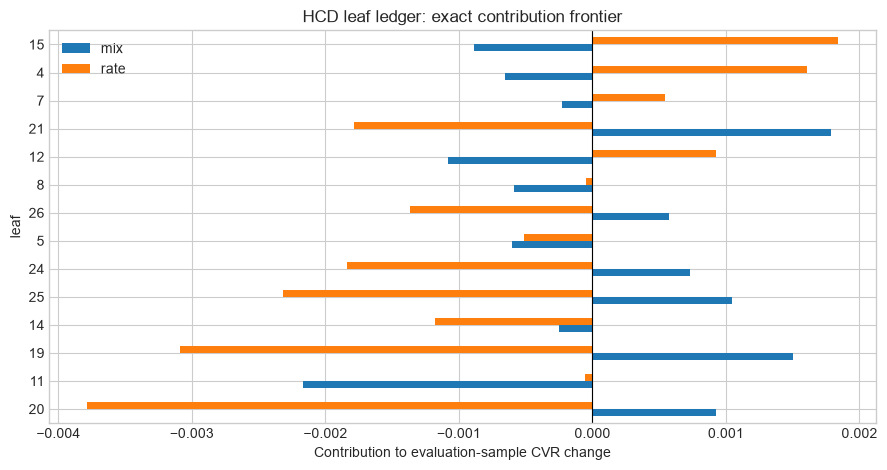

In [9]:
hcd_ledger.sort_values('total_contribution')[['mix', 'rate']].plot.barh(
    figsize=(9, 4.8)
)
plt.axvline(0, color='black', linewidth=.8)
plt.xlabel('Contribution to evaluation-sample CVR change')
plt.title('HCD leaf ledger: exact contribution frontier')
plt.tight_layout()
plt.show()

### Fixed-hierarchy bootstrap

Exactness is algebraic; the estimated contributions still have sampling uncertainty. Because the hierarchy was frozen before looking at `evaluation`, bootstrap observations separately within each period and recompute the complete ledger. Every bootstrap draw should conserve its own resampled aggregate change.

This bootstrap conditions on the discovered tree. It captures uncertainty in shares and rates on evaluation data, but not variability from relearning the hierarchy. To assess full pipeline stability, repeat discovery inside every resample or across temporal folds and compare both leaf membership and contributions.

In [10]:
bootstrap_rng = np.random.default_rng(99)
bootstrap_rows = []
leaf_order = hcd_ledger.index.tolist()
for draw in range(300):
    sampled_parts = []
    for period in [0, 1]:
        period_data = evaluation.loc[evaluation.period.eq(period)]
        sampled_parts.append(period_data.sample(
            n=len(period_data), replace=True,
            random_state=int(bootstrap_rng.integers(0, 2**31-1)),
        ))
    sampled = pd.concat(sampled_parts, ignore_index=True)
    sampled_ledger = exact_leaf_ledger(sampled, 'hcd_leaf').reindex(leaf_order)
    sampled_rates = sampled.groupby('period').converted.mean()
    sampled_change = sampled_rates.loc[1]-sampled_rates.loc[0]
    conservation_error = (
        sampled_ledger.total_contribution.sum()-sampled_change
    )
    for leaf, contribution in sampled_ledger.total_contribution.items():
        bootstrap_rows.append({
            'draw': draw, 'leaf': leaf,
            'total_contribution': contribution,
            'conservation_error': conservation_error,
        })

bootstrap_results = pd.DataFrame(bootstrap_rows)
bootstrap_intervals = bootstrap_results.groupby('leaf').total_contribution.quantile(
    [.025, .5, .975]
).unstack().rename(columns={.025: 'q025', .5: 'median', .975: 'q975'})
bootstrap_diagnostic = pd.Series({
    'draws': bootstrap_results.draw.nunique(),
    'maximum absolute conservation error': (
        bootstrap_results.groupby('draw').conservation_error.first().abs().max()
    ),
})
bootstrap_intervals.join(hcd_ledger[['total_contribution']]), bootstrap_diagnostic

(        q025  median    q975  total_contribution
 leaf                                            
 4    -0.0020  0.0010  0.0037              0.0010
 5    -0.0048 -0.0013  0.0021             -0.0011
 7    -0.0013  0.0005  0.0022              0.0003
 8    -0.0029 -0.0006  0.0017             -0.0006
 11   -0.0072 -0.0021  0.0025             -0.0022
 12   -0.0025 -0.0002  0.0023             -0.0002
 14   -0.0031 -0.0015  0.0005             -0.0014
 15   -0.0014  0.0010  0.0035              0.0010
 19   -0.0046 -0.0017  0.0010             -0.0016
 20   -0.0051 -0.0030 -0.0010             -0.0029
 21   -0.0027 -0.0002  0.0026              0.0000
 24   -0.0041 -0.0010  0.0014             -0.0011
 25   -0.0033 -0.0011  0.0010             -0.0013
 26   -0.0036 -0.0008  0.0019             -0.0008,
 draws                                 300.0000
 maximum absolute conservation error     0.0000
 dtype: float64)

## 7. Convert a pattern into a mechanism hypothesis

Select a leaf because it is material, replicated, sufficiently large, and actionable—not merely because it ranks first. The tree and ledger support a statement such as:

> “The largest negative holdout contribution is concentrated in the population defined by this frozen tree path; most of its contribution is associated with within-leaf rate change rather than share movement.”

Next inspect funnel diagnostics, instrumentation, page speed, creative, inventory, and policy history. Suppose the product review suggests that the mobile landing page mismatches high-intent Paid Search queries. That is a mechanism hypothesis, still not a causal conclusion.

The intervention is now explicit: a faster, query-matched landing experience. The discovered leaf determines eligibility for a future experiment; experiment assignment remains randomized inside that population.

In [11]:
# Choose the most negative replicated leaf and quantify its footprint.
candidate_leaf = hcd_ledger.total_contribution.idxmin()
candidate = hcd_ledger.loc[candidate_leaf]
candidate_rule = describe_leaf(
    hcd_tree.tree_, candidate_leaf, tree_feature_names
)
candidate_summary = pd.Series({
    'candidate leaf': candidate_leaf,
    'frozen rule': candidate_rule,
    'evaluation baseline sessions': candidate.n0,
    'evaluation comparison sessions': candidate.n1,
    'rate change': candidate.rate_change,
    'total KPI contribution': candidate.total_contribution,
    'share of signed aggregate change': (
        candidate.total_contribution / eval_change if eval_change != 0 else np.nan
    ),
})
print('Frozen rule:', candidate_rule)
print(candidate_summary.drop('frozen rule').to_string())

Frozen rule: cat__channel_Paid Search > 0.5 AND num__tenure_months <= 10.8 AND cat__device_Desktop <= 0.5 AND num__high_intent > 0.5
candidate leaf                           20
evaluation baseline sessions       307.0000
evaluation comparison sessions     387.0000
rate change                         -0.0687
total KPI contribution              -0.0029
share of signed aggregate change     0.2609


## 8. Randomized causal validation

Generate a future eligible population using the same feature schema, route it through the frozen tree, and retain the candidate leaf. Randomly assign the new landing experience:

$$
D_i\sim\operatorname{Bernoulli}(0.5).
$$

Under random assignment, consistency, and no interference, the difference in conversion rates estimates the sample average treatment effect for eligible sessions:

$$
\widehat\tau=\overline Y_{D=1}-\overline Y_{D=0}.
$$

This effect is causal for the experimental population. Transporting it to future traffic additionally assumes that the eligible population and implementation remain comparable.

In [12]:
future = simulate_month(1, 30_000).drop(columns='converted')
future_X = transformer.transform(future[features])
future['hcd_leaf'] = hcd_tree.apply(future_X)
eligible = future.loc[future.hcd_leaf.eq(candidate_leaf)].copy()
eligible['treatment'] = rng.binomial(1, .5, len(eligible))

# A transparent experimental DGP: the new experience adds 2.5 pp.
baseline_probability = np.clip(
    candidate.r1 + .012*(eligible.high_intent-eligible.high_intent.mean()),
    .005, .95,
)
true_experiment_lift = .025
eligible['converted'] = rng.binomial(
    1, np.clip(baseline_probability
               + true_experiment_lift*eligible.treatment, 0, 1)
)

experiment = eligible.groupby('treatment').converted.agg(['mean', 'size'])
lift = experiment.loc[1, 'mean'] - experiment.loc[0, 'mean']
lift_se = np.sqrt(
    experiment.loc[1, 'mean']*(1-experiment.loc[1, 'mean'])/experiment.loc[1, 'size']
    + experiment.loc[0, 'mean']*(1-experiment.loc[0, 'mean'])/experiment.loc[0, 'size']
)
experiment_readout = pd.Series({
    'eligible sessions': len(eligible),
    'control CVR': experiment.loc[0, 'mean'],
    'treatment CVR': experiment.loc[1, 'mean'],
    'estimated lift': lift,
    '95% CI low': lift-1.96*lift_se,
    '95% CI high': lift+1.96*lift_se,
    'true simulated lift': true_experiment_lift,
})
experiment, experiment_readout

(            mean  size
 treatment             
 0         0.0411   876
 1         0.0570   877,
 eligible sessions     1,753.0000
 control CVR               0.0411
 treatment CVR             0.0570
 estimated lift            0.0159
 95% CI low               -0.0043
 95% CI high               0.0361
 true simulated lift       0.0250
 dtype: float64)

## 9. Translate lift into an economic decision

Statistical significance is not the launch criterion. Let $N_E$ be expected eligible sessions, $v$ contribution margin per incremental conversion, $C_F$ fixed implementation cost, and $c$ variable cost per treated session. Expected incremental value is

$$
V=N_E\widehat\tau v-C_F-N_Ec.
$$

Use the confidence interval to construct downside and upside scenarios. This calculation assumes the experimental lift transports to the planned rollout volume and that no general-equilibrium, novelty, or interference effects appear.

In [13]:
monthly_eligible_sessions = 80_000
margin_per_conversion = 42.0
fixed_monthly_cost = 35_000.0
variable_cost_per_session = .08

def net_value(effect):
    return (
        monthly_eligible_sessions * effect * margin_per_conversion
        - fixed_monthly_cost
        - monthly_eligible_sessions * variable_cost_per_session
    )

economics = pd.Series({
    'incremental conversions at point estimate': monthly_eligible_sessions*lift,
    'net monthly value — point estimate': net_value(lift),
    'net monthly value — CI low': net_value(lift-1.96*lift_se),
    'net monthly value — CI high': net_value(lift+1.96*lift_se),
    'break-even lift': (
        fixed_monthly_cost + monthly_eligible_sessions*variable_cost_per_session
    ) / (monthly_eligible_sessions*margin_per_conversion),
})
economics

incremental conversions at point estimate     1,273.3322
net monthly value — point estimate           12,079.9519
net monthly value — CI low                  -55,814.8296
net monthly value — CI high                  79,974.7334
break-even lift                                   0.0123
dtype: float64

## 10. Final Growth readout

A defensible one-page conclusion contains four separate panels.

### A. Observed KPI

Report baseline, comparison, absolute percentage-point change, denominators, metric definition, and QA status.

### B. Exact descriptive decomposition

Report Kitagawa mix/rate totals for the joint operational hierarchy. When separate multidimensional labels are decision-relevant, add a Das Gupta/Shapley table with the factorization and reversal sensitivity stated explicitly. Report conservation errors for both views and never add their components together. Do not call either table incremental effects.

### C. Replicated localization

Report the frozen HCD leaf rule, both-period support, rates, total contribution, mix/rate refinement, and holdout interval. Note that ranking was learned on separate data.

### D. Causal and economic validation

Report randomization unit, eligibility, treatment/control sizes, lift and interval, guardrails, expected eligible volume, break-even lift, and value scenarios.

The recommended action can be:

- **launch** when replicated lift and downside economics clear thresholds;
- **iterate and retest** when the point estimate is promising but uncertainty crosses break-even;
- **do not launch** when the intervention fails even if the descriptive leaf was real.

A failed experiment does not invalidate the decomposition. It rejects this intervention or mechanism as the remedy for the localized descriptive change.

## Production checklist

- [ ] Metric contract versioned and reviewed.
- [ ] Numerator, denominator, population, and attribution window stable.
- [ ] Known-segment decomposition conserves the observed change.
- [ ] Adaptive discovery uses only approved pre-outcome descriptors.
- [ ] Final hierarchy is frozen before evaluation.
- [ ] Every leaf has support in both periods or an explicit entry/exit policy.
- [ ] One partition frontier—and only one—is summed.
- [ ] Descriptive and causal tables use different labels.
- [ ] Experiment assignment, exclusions, and guardrails are preregistered.
- [ ] Economics include uncertainty and transport assumptions.

## Limitations

- The simulation is cleaner than real event data and contains no delayed conversions.
- A single discovery/evaluation split does not measure full hierarchy instability.
- CART is used as a candidate partition generator, not a complete optimized HCD estimator.
- The rate-change interval ignores uncertainty from selecting the hierarchy, mitigated but not eliminated by holdout evaluation.
- The fixed-hierarchy bootstrap does not include variability from relearning the tree.
- Multidimensional allocations are exact conditional on their hybrid-population factorization, not invariant scientific truths.
- The experiment targets one discovered leaf; operational eligibility errors can dilute lift.
- Exact conservation makes the ledger auditable, not causal or uniquely invariant to segmentation.

## Exercises

1. Add a new channel that appears only in period 1 and implement the entry/exit policy.
2. Repeat discovery over 30 random splits and calculate leaf-membership stability.
3. Replace the greedy tree score with contribution-at-risk.
4. Compare direct channel × device decomposition with the HCD leaf frontier.
5. Add a negative guardrail effect and formulate a constrained launch decision.
6. Run the experiment on all traffic and estimate treatment-effect heterogeneity honestly.
7. Replace conversion with revenue per session and determine which accounting identity changes.

## References

- Kitagawa, E. M. (1955). Components of a difference between two rates. *JASA*, 50, 1168–1194.
- Das Gupta, P. (1978). A general method of decomposing a difference between two rates into several components. *Demography*, 15, 99–112.
- Breiman, L., Friedman, J. H., Olshen, R. A., & Stone, C. J. (1984). *Classification and Regression Trees*.
- Athey, S., & Imbens, G. (2016). Recursive partitioning for heterogeneous causal effects. *PNAS*, 113, 7353–7360.
- Kohavi, R., Tang, D., & Xu, Y. (2020). *Trustworthy Online Controlled Experiments*. Cambridge University Press.
- Working-paper companion: `working_paper/hierarchical_counterfactual_decomposition.md`.